In [1]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


# MediLens AI — Chest X-ray Model

## Dataset
Organizer-provided chest X-ray dataset.

- 678 NORMAL images initially identified
- 1 corrupted NORMAL image excluded
- 677 usable NORMAL images
- 390 PNEUMONIA images in the provided evaluation set

## Approach
A NORMAL-only anomaly detection approach was used because the provided training split contained NORMAL images while the provided evaluation split contained PNEUMONIA images.

Pipeline:

Chest X-ray
→ 224×224 preprocessing
→ Grayscale to RGB
→ DenseNet121 feature extraction
→ 1024-dimensional feature vector
→ NORMAL centroid
→ Euclidean anomaly distance
→ Threshold
→ NORMAL-LIKE / ABNORMAL_PATTERN

## Current Status
- Dataset exploration: Complete
- Preprocessing: Complete
- Train/validation split: Complete
- DenseNet121 feature extraction: Complete
- Anomaly detector: Complete
- Prototype inference: Complete
- FastAPI integration: Pending

## Prototype Evaluation
At the current threshold derived from the NORMAL validation set:

95 / 390 provided PNEUMONIA images were flagged as abnormal.

Detection rate: 24.36%.

This is an initial dataset-specific prototype result and should not be interpreted as clinical accuracy or diagnostic performance.

## Disclaimer
This project is a hackathon prototype and is not intended for clinical diagnosis.

In [2]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Getting started.pdf', 'PHOTO-2020-04-25-09-48-39.jpg', 'IMG_8398.jpg', 'new doc 3.pdf', 'new doc 3 (1).gdoc', 'new doc 3.gdoc', 'new doc 4.pdf', 'new doc 4.gdoc', 'new doc 5.pdf', 'new doc 6 (2).pdf', 'new doc 7_1.jpg', 'new doc 9.zip', 'new doc 10 (1).pdf', 'new doc 11 (1).pdf', 'new doc 12.pdf', 'new doc 13 (1).pdf', 'new doc 14.pdf', 'new doc 15 (1).pdf', 'new doc 16 (4).pdf', 'new doc 16 (3).pdf', 'videoplayback (1).mp4', 'new doc 26.pdf', 'new doc 27.pdf', 'new doc 30.pdf', 'new doc 31.pdf', 'Classroom', 'Jun 28, 2020 8:48:34 PM.jpeg', 'VID20200717105024.mp4', 'new doc 6 (1).pdf', 'new doc 6.pdf', 'new doc 7 (1).pdf', 'new doc 8 (1).pdf', 'new doc 10.pdf', 'new doc 13.pdf', 'new doc 15.pdf', 'new doc 16 (2).pdf', 'new doc 8.pdf', 'new doc 17 (1).pdf', 'new doc 18 (1).pdf', 'new doc 19.pdf', 'new doc 20.pdf', 'new doc 21.pdf', 'new doc 16 (1).pdf', 'new doc 22.pdf', 'new doc 7.pdf', 'new doc 11.pdf', 'new doc 16.pdf', 'new doc 17.pdf', 'new doc 18.pdf', 'new doc 23.pdf', 'new doc

In [3]:
import os

print(os.listdir('/content/drive/MyDrive'))


['Getting started.pdf', 'PHOTO-2020-04-25-09-48-39.jpg', 'IMG_8398.jpg', 'new doc 3.pdf', 'new doc 3 (1).gdoc', 'new doc 3.gdoc', 'new doc 4.pdf', 'new doc 4.gdoc', 'new doc 5.pdf', 'new doc 6 (2).pdf', 'new doc 7_1.jpg', 'new doc 9.zip', 'new doc 10 (1).pdf', 'new doc 11 (1).pdf', 'new doc 12.pdf', 'new doc 13 (1).pdf', 'new doc 14.pdf', 'new doc 15 (1).pdf', 'new doc 16 (4).pdf', 'new doc 16 (3).pdf', 'videoplayback (1).mp4', 'new doc 26.pdf', 'new doc 27.pdf', 'new doc 30.pdf', 'new doc 31.pdf', 'Classroom', 'Jun 28, 2020 8:48:34 PM.jpeg', 'VID20200717105024.mp4', 'new doc 6 (1).pdf', 'new doc 6.pdf', 'new doc 7 (1).pdf', 'new doc 8 (1).pdf', 'new doc 10.pdf', 'new doc 13.pdf', 'new doc 15.pdf', 'new doc 16 (2).pdf', 'new doc 8.pdf', 'new doc 17 (1).pdf', 'new doc 18 (1).pdf', 'new doc 19.pdf', 'new doc 20.pdf', 'new doc 21.pdf', 'new doc 16 (1).pdf', 'new doc 22.pdf', 'new doc 7.pdf', 'new doc 11.pdf', 'new doc 16.pdf', 'new doc 17.pdf', 'new doc 18.pdf', 'new doc 23.pdf', 'new doc

In [4]:
import os

print(os.listdir('/content/drive/MyDrive/healthcare'))


['stroke_prediction.csv', 'CT_MedicalImages.zip', '.DS_Store', 'heart disease tabular', 'chest xray', 'ecg signals']


In [5]:
print(os.listdir('/content/drive/MyDrive/healthcare/chest xray'))

['test', 'train']


In [6]:
train_path = '/content/drive/MyDrive/healthcare/chest xray/train'

print(os.listdir(train_path))

['.DS_Store', 'NORMAL']


In [7]:
test_path = '/content/drive/MyDrive/healthcare/chest xray/test'

print(os.listdir(test_path))

['.DS_Store', 'NORMAL', 'PNEUMONIA']


In [8]:
import os

normal_train = os.listdir(
    '/content/drive/MyDrive/healthcare/chest xray/train/NORMAL'
)

print("Number of training images:", len(normal_train))

Number of training images: 679


In [9]:
normal_test = os.listdir(
    '/content/drive/MyDrive/healthcare/chest xray/test/NORMAL'
)

print("Number of NORMAL test images:", len(normal_test))

Number of NORMAL test images: 0


In [10]:
pneumonia_test = os.listdir(
    '/content/drive/MyDrive/healthcare/chest xray/test/PNEUMONIA'
)

print("Number of PNEUMONIA test images:", len(pneumonia_test))

Number of PNEUMONIA test images: 390


In [11]:
import os

train_files = os.listdir(
    '/content/drive/MyDrive/healthcare/chest xray/train/NORMAL'
)

test_files = os.listdir(
    '/content/drive/MyDrive/healthcare/chest xray/test/PNEUMONIA'
)

train_images = [
    f for f in train_files
    if f.lower().endswith(('.jpeg', '.jpg', '.png'))
]

test_images = [
    f for f in test_files
    if f.lower().endswith(('.jpeg', '.jpg', '.png'))
]

print("Actual NORMAL training images:", len(train_images))
print("Actual PNEUMONIA test images:", len(test_images))

Actual NORMAL training images: 678
Actual PNEUMONIA test images: 390


In [12]:
from PIL import Image
import os

In [13]:
train_normal_path = '/content/drive/MyDrive/healthcare/chest xray/train/NORMAL'

print(train_normal_path)

/content/drive/MyDrive/healthcare/chest xray/train/NORMAL


In [14]:
files = [
    f for f in os.listdir(train_normal_path)
    if f.lower().endswith(('.jpeg', '.jpg', '.png'))
]

print(files[0])

IM-0145-0001.jpeg


In [15]:
image_path = os.path.join(train_normal_path, files[0])

img = Image.open(image_path)

print("Image size:", img.size)
print("Image mode:", img.mode)

Image size: (1596, 1156)
Image mode: L


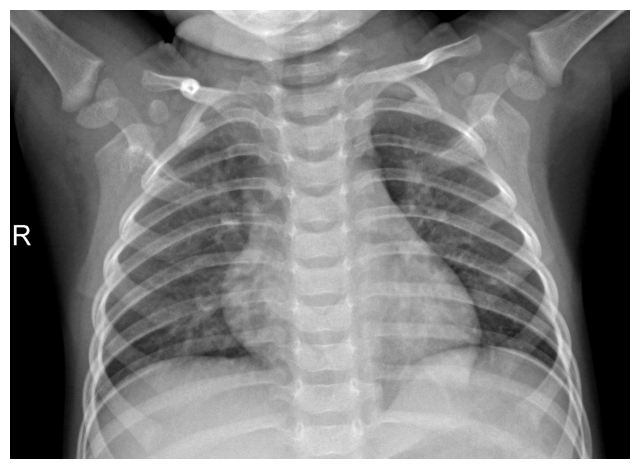

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(img, cmap='gray')

plt.axis('off')

plt.show()

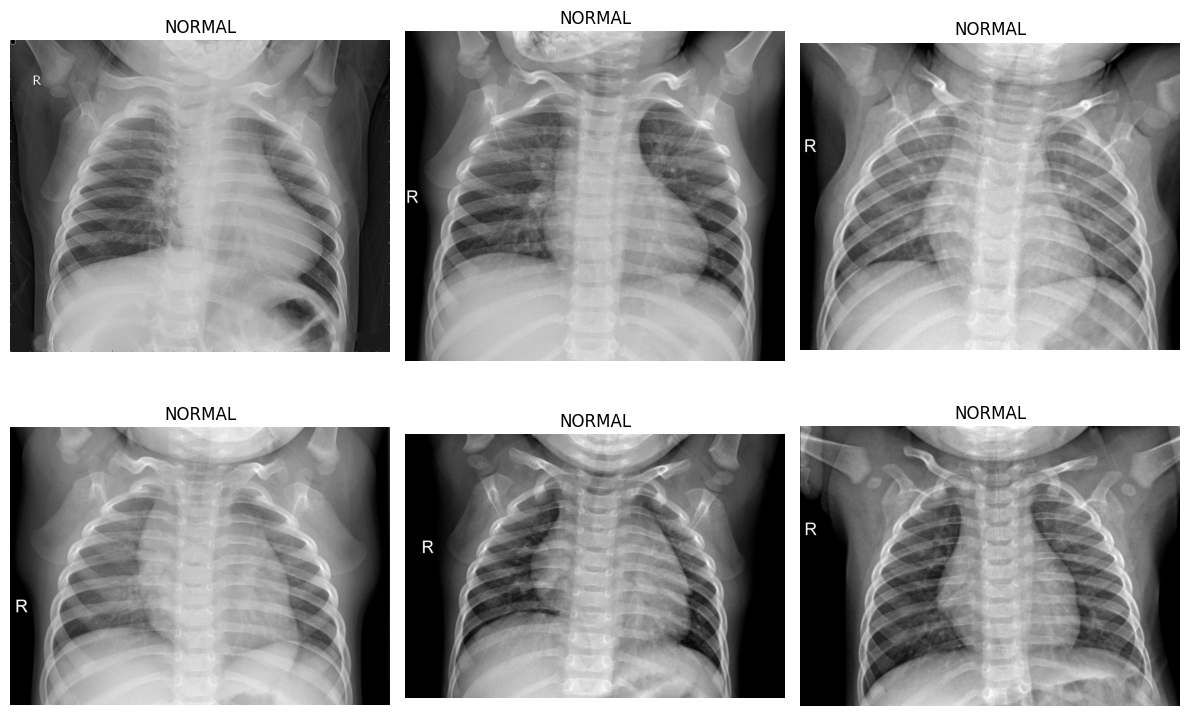

In [17]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# Pick 6 random X-rays
random_files = random.sample(files, 6)

plt.figure(figsize=(12, 8))

for i, filename in enumerate(random_files):

    image_path = os.path.join(train_normal_path, filename)

    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)

    plt.imshow(image, cmap='gray')

    plt.title("NORMAL")

    plt.axis('off')

plt.tight_layout()
plt.show()

In [18]:
pneumonia_path = '/content/drive/MyDrive/healthcare/chest xray/test/PNEUMONIA'

pneumonia_files = [
    f for f in os.listdir(pneumonia_path)
    if f.lower().endswith(('.jpeg', '.jpg', '.png'))
]

print("Number of pneumonia images:", len(pneumonia_files))

Number of pneumonia images: 390


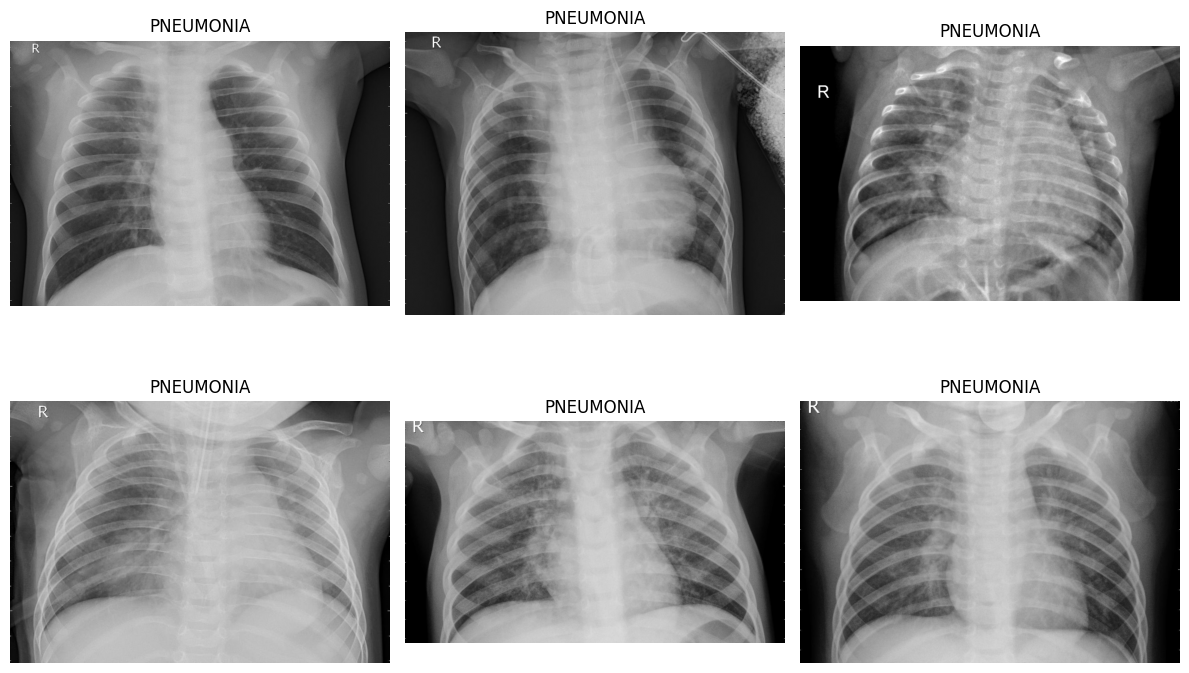

In [19]:
random_pneumonia = random.sample(pneumonia_files, 6)

plt.figure(figsize=(12, 8))

for i, filename in enumerate(random_pneumonia):

    image_path = os.path.join(pneumonia_path, filename)

    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)

    plt.imshow(image, cmap='gray')

    plt.title("PNEUMONIA")

    plt.axis('off')

plt.tight_layout()
plt.show()

In [20]:
print("NORMAL example:")
print(files[:5])

print("\nPNEUMONIA example:")
print(pneumonia_files[:5])

NORMAL example:
['IM-0145-0001.jpeg', 'IM-0168-0001.jpeg', 'IM-0133-0001.jpeg', 'IM-0151-0001.jpeg', 'IM-0162-0001.jpeg']

PNEUMONIA example:
['person109_bacteria_522.jpeg', 'person109_bacteria_519.jpeg', 'person100_bacteria_477.jpeg', 'person100_bacteria_482.jpeg', 'person108_bacteria_506.jpeg']


In [21]:
import os

normal_files = [
    f for f in os.listdir(train_normal_path)
    if f.lower().endswith(('.jpeg', '.jpg', '.png'))
]

print("Total NORMAL images:", len(normal_files))

print("\nFirst 20 filenames:")
for f in normal_files[:20]:
    print(f)

Total NORMAL images: 678

First 20 filenames:
IM-0145-0001.jpeg
IM-0168-0001.jpeg
IM-0133-0001.jpeg
IM-0151-0001.jpeg
IM-0162-0001.jpeg
IM-0156-0001.jpeg
IM-0143-0001.jpeg
IM-0170-0001.jpeg
IM-0140-0001.jpeg
IM-0135-0001.jpeg
IM-0115-0001.jpeg
IM-0164-0001.jpeg
IM-0119-0001.jpeg
IM-0127-0001.jpeg
IM-0149-0001.jpeg
IM-0207-0001.jpeg
IM-0176-0001.jpeg
IM-0189-0001.jpeg
IM-0218-0001.jpeg
IM-0221-0001.jpeg


In [22]:
from PIL import Image
import os

sizes = {}

for f in normal_files:
    path = os.path.join(train_normal_path, f)
    img = Image.open(path)
    size = img.size

    if size not in sizes:
        sizes[size] = 0
    sizes[size] += 1

print("Different image sizes found:", len(sizes))

print("\nImage sizes:")
for size, count in sizes.items():
    print(size, "->", count, "images")

Different image sizes found: 674

Image sizes:
(1596, 1156) -> 1 images
(1534, 1187) -> 1 images
(1468, 993) -> 1 images
(1518, 1156) -> 1 images
(1762, 1430) -> 1 images
(1488, 1209) -> 1 images
(2138, 1928) -> 1 images
(2148, 1496) -> 1 images
(1156, 1237) -> 1 images
(1724, 1581) -> 1 images
(2090, 1858) -> 1 images
(1202, 808) -> 1 images
(1810, 1434) -> 1 images
(1974, 1306) -> 1 images
(1542, 1152) -> 1 images
(1426, 1049) -> 1 images
(1680, 1557) -> 1 images
(1466, 1109) -> 1 images
(1678, 1654) -> 1 images
(1804, 1480) -> 1 images
(2172, 1615) -> 1 images
(1666, 1209) -> 1 images
(1774, 1546) -> 1 images
(1854, 1572) -> 1 images
(2136, 1650) -> 1 images
(1446, 1310) -> 1 images
(1928, 1303) -> 1 images
(1592, 1272) -> 1 images
(1506, 833) -> 1 images
(1522, 1221) -> 1 images
(2010, 1747) -> 1 images
(1040, 747) -> 1 images
(1484, 1399) -> 1 images
(1682, 1418) -> 1 images
(1724, 1480) -> 1 images
(1346, 1109) -> 1 images
(1816, 1500) -> 1 images
(1690, 1314) -> 1 images
(1690, 

In [23]:
widths = []
heights = []

for f in normal_files:
    path = os.path.join(train_normal_path, f)
    img = Image.open(path)
    width, height = img.size

    widths.append(width)
    heights.append(height)

print("Smallest width:", min(widths))
print("Largest width:", max(widths))

print("Smallest height:", min(heights))
print("Largest height:", max(heights))

Smallest width: 1040
Largest width: 2916
Smallest height: 747
Largest height: 2663


In [24]:
pneumonia_widths = []
pneumonia_heights = []

for f in pneumonia_files:
    path = os.path.join(pneumonia_path, f)
    img = Image.open(path)
    width, height = img.size

    pneumonia_widths.append(width)
    pneumonia_heights.append(height)

print("Smallest width:", min(pneumonia_widths))
print("Largest width:", max(pneumonia_widths))

print("Smallest height:", min(pneumonia_heights))
print("Largest height:", max(pneumonia_heights))

Smallest width: 728
Largest width: 2000
Smallest height: 344
Largest height: 1456


In [25]:
sample_path = os.path.join(train_normal_path, normal_files[0])

sample_img = Image.open(sample_path)

print("Image mode:", sample_img.mode)
print("Minimum pixel value:", min(sample_img.getdata()))
print("Maximum pixel value:", max(sample_img.getdata()))

Image mode: L
Minimum pixel value: 0
Maximum pixel value: 255


In [26]:
from PIL import Image
import os

bad_files = []

for f in normal_files:
    path = os.path.join(train_normal_path, f)

    try:
        img = Image.open(path)
        img.verify()
    except:
        bad_files.append(f)

print("Corrupted NORMAL images:", len(bad_files))

if bad_files:
    print("Bad files:")
    for f in bad_files:
        print(f)

Corrupted NORMAL images: 0


Original size: (1596, 1156)
Processed size: (224, 224)


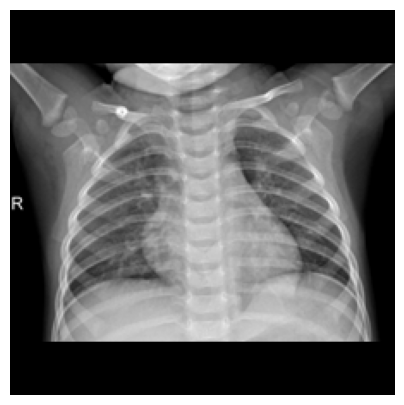

In [27]:
from PIL import Image, ImageOps
import os
import matplotlib.pyplot as plt

# Pick one NORMAL X-ray
sample_path = os.path.join(train_normal_path, normal_files[0])

# Open it
img = Image.open(sample_path).convert("L")

# Resize while keeping the original proportions
img.thumbnail((224, 224))

# Add padding to make it exactly 224 × 224
img_padded = ImageOps.pad(
    img,
    (224, 224),
    method=Image.Resampling.LANCZOS,
    color=0
)

print("Original size:", Image.open(sample_path).size)
print("Processed size:", img_padded.size)

plt.figure(figsize=(5, 5))
plt.imshow(img_padded, cmap="gray")
plt.axis("off")
plt.show()

In [28]:
processed_path = '/content/drive/MyDrive/healthcare/chest xray/processed'

os.makedirs(processed_path, exist_ok=True)

print("Processed folder created!")
print("Location:", processed_path)

OSError: [Errno 30] Read-only file system: '/content/drive/MyDrive/healthcare/chest xray/processed'

In [ ]:
processed_path = '/content/drive/MyDrive/MediLens_XRay_Processed'

os.makedirs(processed_path, exist_ok=True)

print("Processed folder created!")
print("Location:", processed_path)

In [ ]:
normal_processed_path = os.path.join(processed_path, 'NORMAL')
pneumonia_processed_path = os.path.join(processed_path, 'PNEUMONIA')

os.makedirs(normal_processed_path, exist_ok=True)
os.makedirs(pneumonia_processed_path, exist_ok=True)

print("NORMAL folder created:", normal_processed_path)
print("PNEUMONIA folder created:", pneumonia_processed_path)

In [ ]:
test_output_path = os.path.join(
    normal_processed_path,
    'test_normal.jpeg'
)

img_padded.save(test_output_path)

print("Saved successfully!")
print("File:", test_output_path)

In [ ]:
saved_img = Image.open(test_output_path)

print("Saved image size:", saved_img.size)
print("Saved image mode:", saved_img.mode)

In [ ]:
if os.path.exists(test_output_path):
    os.remove(test_output_path)

print("Test image removed.")

In [ ]:
from PIL import Image, ImageOps
import os

processed_count = 0
failed_count = 0

for f in normal_files:
    input_path = os.path.join(train_normal_path, f)
    output_path = os.path.join(normal_processed_path, f)

    try:
        # Open and convert to grayscale
        img = Image.open(input_path).convert("L")

        # Resize while preserving proportions
        img.thumbnail((224, 224))

        # Pad to exactly 224 × 224
        img_padded = ImageOps.pad(
            img,
            (224, 224),
            method=Image.Resampling.LANCZOS,
            color=0
        )

        # Save processed image
        img_padded.save(output_path)

        processed_count += 1

    except Exception as e:
        failed_count += 1
        print("Failed:", f, "|", e)

print("\nProcessing complete!")
print("Successfully processed:", processed_count)
print("Failed:", failed_count)

In [ ]:
processed_files = [
    f for f in os.listdir(normal_processed_path)
    if f.lower().endswith(('.jpeg', '.jpg', '.png'))
]

print("Processed NORMAL images:", len(processed_files))

In [ ]:
import random
import matplotlib.pyplot as plt

sample_files = random.sample(processed_files, 6)

plt.figure(figsize=(12, 8))

for i, f in enumerate(sample_files):
    img = Image.open(os.path.join(normal_processed_path, f))

    plt.subplot(2, 3, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
pneumonia_processed_count = 0
pneumonia_failed_count = 0

for f in pneumonia_files:
    input_path = os.path.join(pneumonia_path, f)
    output_path = os.path.join(pneumonia_processed_path, f)

    try:
        img = Image.open(input_path).convert("L")

        # Resize while preserving proportions
        img.thumbnail((224, 224))

        # Pad to exactly 224 × 224
        img_padded = ImageOps.pad(
            img,
            (224, 224),
            method=Image.Resampling.LANCZOS,
            color=0
        )

        img_padded.save(output_path)

        pneumonia_processed_count += 1

    except Exception as e:
        pneumonia_failed_count += 1
        print("Failed:", f, "|", e)

print("\nPNEUMONIA processing complete!")
print("Successfully processed:", pneumonia_processed_count)
print("Failed:", pneumonia_failed_count)

In [ ]:
pneumonia_processed_files = [
    f for f in os.listdir(pneumonia_processed_path)
    if f.lower().endswith(('.jpeg', '.jpg', '.png'))
]

print("Processed PNEUMONIA images:", len(pneumonia_processed_files))

In [ ]:
sample_pneumonia = random.sample(pneumonia_processed_files, 6)

plt.figure(figsize=(12, 8))

for i, f in enumerate(sample_pneumonia):
    img = Image.open(os.path.join(pneumonia_processed_path, f))

    plt.subplot(2, 3, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

In [ ]:
from tensorflow.keras.applications import DenseNet121

densenet = DenseNet121(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

print("DenseNet121 loaded successfully!")
print("Output shape:", densenet.output_shape)

In [ ]:
from sklearn.model_selection import train_test_split

normal_train_files, normal_val_files = train_test_split(
    processed_files,
    test_size=0.2,
    random_state=42
)

print("NORMAL training images:", len(normal_train_files))
print("NORMAL validation images:", len(normal_val_files))

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    normal_processed_path.rsplit('/', 1)[0],
    classes=['NORMAL'],
    target_size=(224, 224),
    color_mode='grayscale',
    batch_size=16,
    shuffle=True,
    seed=42
)

print("Training generator created!")

In [ ]:
train_split_path = os.path.join(processed_path, 'train')
val_split_path = os.path.join(processed_path, 'val')

os.makedirs(train_split_path, exist_ok=True)
os.makedirs(val_split_path, exist_ok=True)

print("Train split folder:", train_split_path)
print("Validation split folder:", val_split_path)

In [ ]:
import shutil
import os

copied = 0

for f in normal_train_files:
    source = os.path.join(normal_processed_path, f)
    destination = os.path.join(train_split_path, f)

    shutil.copy2(source, destination)
    copied += 1



In [ ]:
import shutil
import os

copied = 0

for f in normal_train_files:
    source = os.path.join(normal_processed_path, f)
    destination = os.path.join(train_split_path, f)

    shutil.copy2(source, destination)
    copied += 1

print("Training images copied:", copied)

In [ ]:
copy_val_count = 0

for f in normal_val_files:
    source = os.path.join(normal_processed_path, f)
    destination = os.path.join(val_split_path, f)

    shutil.copy2(source, destination)
    copy_val_count += 1

print("Validation images copied:", copy_val_count)

In [ ]:
id="verify_split_01"
train_check = [
    f for f in os.listdir(train_split_path)
    if f.lower().endswith(('.jpeg', '.jpg', '.png'))
]

val_check = [
    f for f in os.listdir(val_split_path)
    if f.lower().endswith(('.jpeg', '.jpg', '.png'))
]

print("Training folder:", len(train_check))
print("Validation folder:", len(val_check))
print("Total:", len(train_check) + len(val_check))

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_split_path,
    target_size=(224, 224),
    color_mode='grayscale',
    class_mode=None,
    batch_size=16,
    shuffle=True,
    seed=42
)

print("Training generator ready!")

In [ ]:
train_normal_path = os.path.join(train_split_path, 'NORMAL')
val_normal_path = os.path.join(val_split_path, 'NORMAL')

os.makedirs(train_normal_path, exist_ok=True)
os.makedirs(val_normal_path, exist_ok=True)

print("Train NORMAL folder:", train_normal_path)
print("Validation NORMAL folder:", val_normal_path)

In [ ]:
import shutil
import os

moved_train = 0

for f in normal_train_files:
    source = os.path.join(train_split_path, f)
    destination = os.path.join(train_normal_path, f)

    shutil.move(source, destination)
    moved_train += 1

print("Training images moved:", moved_train)

In [ ]:
moved_val = 0

for f in normal_val_files:
    source = os.path.join(val_split_path, f)
    destination = os.path.join(val_normal_path, f)

    shutil.move(source, destination)
    moved_val += 1

print("Validation images moved:", moved_val)

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_split_path,
    target_size=(224, 224),
    color_mode='grayscale',
    class_mode=None,
    batch_size=16,
    shuffle=True,
    seed=42
)

print("Training generator ready!")

In [ ]:
val_datagen = ImageDataGenerator(
    rescale=1./255
)

val_generator = val_datagen.flow_from_directory(
    val_split_path,
    target_size=(224, 224),
    color_mode='grayscale',
    class_mode=None,
    batch_size=16,
    shuffle=False
)

print("Validation generator ready!")

In [ ]:
batch = next(train_generator)

print("Batch shape:", batch.shape)
print("Minimum pixel value:", batch.min())
print("Maximum pixel value:", batch.max())

In [ ]:
import tensorflow as tf

rgb_batch = tf.image.grayscale_to_rgb(batch)

print("Original batch shape:", batch.shape)
print("RGB batch shape:", rgb_batch.shape)

In [ ]:
import tensorflow as tf

# Convert NumPy array to a TensorFlow tensor
batch_tensor = tf.convert_to_tensor(batch)

# Convert grayscale (1 channel) to RGB (3 channels)
rgb_batch = tf.image.grayscale_to_rgb(batch_tensor)

print("Original batch shape:", batch.shape)
print("RGB batch shape:", rgb_batch.shape)

In [ ]:
from tensorflow.keras.applications.densenet import preprocess_input

# Our batch is currently 0–1
# Convert it back to 0–255 first
batch_255 = batch * 255.0

# Convert grayscale → RGB
batch_rgb = tf.image.grayscale_to_rgb(
    tf.convert_to_tensor(batch_255)
)

# Apply DenseNet121's ImageNet preprocessing
batch_preprocessed = preprocess_input(batch_rgb)

print("Shape:", batch_preprocessed.shape)
print("Minimum value:", tf.reduce_min(batch_preprocessed).numpy())
print("Maximum value:", tf.reduce_max(batch_preprocessed).numpy())

In [ ]:
features = densenet.predict(
    batch_preprocessed,
    verbose=0
)

print("Feature shape:", features.shape)

In [ ]:
print("Trainable layers:", sum(layer.trainable for layer in densenet.layers))
print("Total layers:", len(densenet.layers))

In [ ]:
densenet.trainable = False

print("Trainable layers:", sum(layer.trainable for layer in densenet.layers))
print("Total layers:", len(densenet.layers))

In [ ]:
train_datagen_densenet = ImageDataGenerator()

train_generator_densenet = train_datagen_densenet.flow_from_directory(
    train_split_path,
    target_size=(224, 224),
    color_mode='grayscale',
    class_mode=None,
    batch_size=16,
    shuffle=False
)

print("DenseNet training generator ready!")

In [ ]:
batch_raw = next(train_generator_densenet)

print("Batch shape:", batch_raw.shape)
print("Minimum pixel value:", batch_raw.min())
print("Maximum pixel value:", batch_raw.max())

In [ ]:
batch_rgb = tf.image.grayscale_to_rgb(
    tf.convert_to_tensor(batch_raw)
)

batch_preprocessed = preprocess_input(batch_rgb)

print("Preprocessed shape:", batch_preprocessed.shape)
print("Minimum value:", tf.reduce_min(batch_preprocessed).numpy())
print("Maximum value:", tf.reduce_max(batch_preprocessed).numpy())

In [ ]:
import numpy as np

train_features = []

# Reset generator to the beginning
train_generator_densenet.reset()

for i in range(len(train_generator_densenet)):
    batch_raw = next(train_generator_densenet)

    # Grayscale → RGB
    batch_rgb = tf.image.grayscale_to_rgb(
        tf.convert_to_tensor(batch_raw)
    )

    # DenseNet preprocessing
    batch_preprocessed = preprocess_input(batch_rgb)

    # Extract 1024 features
    batch_features = densenet.predict(
        batch_preprocessed,
        verbose=0
    )

    train_features.append(batch_features)

# Combine all batches into one array
train_features = np.concatenate(train_features, axis=0)

print("Training features shape:", train_features.shape)

In [ ]:
val_features = []

val_generator_densenet = ImageDataGenerator().flow_from_directory(
    val_split_path,
    target_size=(224, 224),
    color_mode='grayscale',
    class_mode=None,
    batch_size=16,
    shuffle=False
)

val_generator_densenet.reset()

for i in range(len(val_generator_densenet)):
    batch_raw = next(val_generator_densenet)

    # Grayscale → RGB
    batch_rgb = tf.image.grayscale_to_rgb(
        tf.convert_to_tensor(batch_raw)
    )

    # DenseNet preprocessing
    batch_preprocessed = preprocess_input(batch_rgb)

    # Extract features
    batch_features = densenet.predict(
        batch_preprocessed,
        verbose=0
    )

    val_features.append(batch_features)

val_features = np.concatenate(val_features, axis=0)

print("Validation features shape:", val_features.shape)

In [ ]:
normal_center = np.mean(train_features, axis=0)

print("Normal center shape:", normal_center.shape)

In [ ]:
from sklearn.metrics import pairwise_distances

val_distances = pairwise_distances(
    val_features,
    normal_center.reshape(1, -1),
    metric='euclidean'
).flatten()

print("Number of validation scores:", len(val_distances))
print("Minimum distance:", val_distances.min())
print("Maximum distance:", val_distances.max())
print("Average distance:", val_distances.mean())

In [ ]:
normal_threshold = np.percentile(val_distances, 95)

print("NORMAL anomaly threshold:", normal_threshold)

In [ ]:
pneumonia_datagen = ImageDataGenerator()

pneumonia_generator = pneumonia_datagen.flow_from_directory(
    processed_path,
    classes=['PNEUMONIA'],
    target_size=(224, 224),
    color_mode='grayscale',
    class_mode=None,
    batch_size=16,
    shuffle=False
)

print("PNEUMONIA generator ready!")

In [ ]:
pneumonia_features = []

pneumonia_generator.reset()

for i in range(len(pneumonia_generator)):
    batch_raw = next(pneumonia_generator)

    # Grayscale → RGB
    batch_rgb = tf.image.grayscale_to_rgb(
        tf.convert_to_tensor(batch_raw)
    )

    # DenseNet ImageNet preprocessing
    batch_preprocessed = preprocess_input(batch_rgb)

    # Extract 1024 features
    batch_features = densenet.predict(
        batch_preprocessed,
        verbose=0
    )

    pneumonia_features.append(batch_features)

pneumonia_features = np.concatenate(
    pneumonia_features,
    axis=0
)

print("PNEUMONIA features shape:", pneumonia_features.shape)

In [ ]:
pneumonia_distances = pairwise_distances(
    pneumonia_features,
    normal_center.reshape(1, -1),
    metric='euclidean'
).flatten()

print("Number of PNEUMONIA scores:", len(pneumonia_distances))
print("Minimum distance:", pneumonia_distances.min())
print("Maximum distance:", pneumonia_distances.max())
print("Average distance:", pneumonia_distances.mean())

In [ ]:
from sklearn.metrics import pairwise_distances


In [ ]:
pneumonia_distances = pairwise_distances(
    pneumonia_features,
    normal_center.reshape(1, -1),
    metric='euclidean'
).flatten()

print("Number of PNEUMONIA scores:", len(pneumonia_distances))
print("Minimum distance:", pneumonia_distances.min())
print("Maximum distance:", pneumonia_distances.max())
print("Average distance:", pneumonia_distances.mean())


In [ ]:
pneumonia_features = []

pneumonia_generator.reset()

for i in range(len(pneumonia_generator)):
    batch_raw = next(pneumonia_generator)

    # Grayscale → RGB
    batch_rgb = tf.image.grayscale_to_rgb(
        tf.convert_to_tensor(batch_raw)
    )

    # DenseNet ImageNet preprocessing
    batch_preprocessed = preprocess_input(batch_rgb)

    # Extract 1024 features
    batch_features = densenet.predict(
        batch_preprocessed,
        verbose=0
    )

    pneumonia_features.append(batch_features)

pneumonia_features = np.concatenate(
    pneumonia_features,
    axis=0
)

print("PNEUMONIA features shape:", pneumonia_features.shape)

In [ ]:
pneumonia_datagen = ImageDataGenerator()

pneumonia_generator = pneumonia_datagen.flow_from_directory(
    processed_path,
    classes=['PNEUMONIA'],
    target_size=(224, 224),
    color_mode='grayscale',
    class_mode=None,
    batch_size=16,
    shuffle=False
)

print("PNEUMONIA generator recreated!")


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

pneumonia_datagen = ImageDataGenerator()

pneumonia_generator = pneumonia_datagen.flow_from_directory(
    processed_path,
    classes=['PNEUMONIA'],
    target_size=(224, 224),
    color_mode='grayscale',
    class_mode=None,
    batch_size=16,
    shuffle=False
)

print("PNEUMONIA generator recreated!")

In [ ]:
import os

processed_path = '/content/drive/MyDrive/MediLens_XRay_Processed'

pneumonia_processed_path = os.path.join(
    processed_path,
    'PNEUMONIA'
)

print("Processed folder exists:", os.path.exists(processed_path))
print("PNEUMONIA folder exists:", os.path.exists(pneumonia_processed_path))

print(
    "PNEUMONIA images:",
    len([
        f for f in os.listdir(pneumonia_processed_path)
        if f.lower().endswith(('.jpeg', '.jpg', '.png'))
    ])
)

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

In [29]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Getting started.pdf', 'PHOTO-2020-04-25-09-48-39.jpg', 'IMG_8398.jpg', 'new doc 3.pdf', 'new doc 3 (1).gdoc', 'new doc 3.gdoc', 'new doc 4.pdf', 'new doc 4.gdoc', 'new doc 5.pdf', 'new doc 6 (2).pdf', 'new doc 7_1.jpg', 'new doc 9.zip', 'new doc 10 (1).pdf', 'new doc 11 (1).pdf', 'new doc 12.pdf', 'new doc 13 (1).pdf', 'new doc 14.pdf', 'new doc 15 (1).pdf', 'new doc 16 (4).pdf', 'new doc 16 (3).pdf', 'videoplayback (1).mp4', 'new doc 26.pdf', 'new doc 27.pdf', 'new doc 30.pdf', 'new doc 31.pdf', 'Classroom', 'Jun 28, 2020 8:48:34 PM.jpeg', 'VID20200717105024.mp4', 'new doc 6 (1).pdf', 'new doc 6.pdf', 'new doc 7 (1).pdf', 'new doc 8 (1).pdf', 'new doc 10.pdf', 'new doc 13.pdf', 'new doc 15.pdf', 'new doc 16 (2).pdf', 'new doc 8.pdf', 'new doc 17 (1).pdf', 'new doc 18 (1).pdf', 'new doc 19.pdf', 'new doc 20.pdf', 'new doc 21.pdf', 'new doc 16 (1).pdf', 'new doc 22.pdf', 'new doc 7.pdf', 'new doc 11.pdf', 'new doc 16.pdf', 'new doc 17.pdf', 'new doc 18.pdf', 'new doc 23.pdf', 'new doc

In [31]:
import os

processed_path = '/content/drive/MyDrive/MediLens_XRay_Processed'

print("Processed folder exists:", os.path.exists(processed_path))
print("Contents:", os.listdir(processed_path))

Processed folder exists: True
Contents: ['NORMAL', 'PNEUMONIA', 'train', 'val']


In [32]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

pneumonia_processed_path = os.path.join(
    processed_path,
    'PNEUMONIA'
)

pneumonia_datagen = ImageDataGenerator()

pneumonia_generator = pneumonia_datagen.flow_from_directory(
    processed_path,
    classes=['PNEUMONIA'],
    target_size=(224, 224),
    color_mode='grayscale',
    class_mode=None,
    batch_size=16,
    shuffle=False
)

print("PNEUMONIA generator ready!")

Found 390 images belonging to 1 classes.
PNEUMONIA generator ready!


In [33]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

densenet = DenseNet121(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

densenet.trainable = False

print("DenseNet121 restored!")
print("Output shape:", densenet.output_shape)
print("Trainable layers:", sum(layer.trainable for layer in densenet.layers))

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
DenseNet121 restored!
Output shape: (None, 1024)
Trainable layers: 0


In [34]:
pneumonia_features = []

pneumonia_generator.reset()

for i in range(len(pneumonia_generator)):
    batch_raw = next(pneumonia_generator)

    # Grayscale → RGB
    batch_rgb = tf.image.grayscale_to_rgb(
        tf.convert_to_tensor(batch_raw)
    )

    # DenseNet ImageNet preprocessing
    batch_preprocessed = preprocess_input(batch_rgb)

    # Extract 1024 features
    batch_features = densenet.predict(
        batch_preprocessed,
        verbose=0
    )

    pneumonia_features.append(batch_features)

pneumonia_features = np.concatenate(
    pneumonia_features,
    axis=0
)

print("PNEUMONIA features shape:", pneumonia_features.shape)

PNEUMONIA features shape: (390, 1024)


In [35]:
from sklearn.metrics import pairwise_distances

pneumonia_distances = pairwise_distances(
    pneumonia_features,
    normal_center.reshape(1, -1),
    metric='euclidean'
).flatten()

print("Number of PNEUMONIA scores:", len(pneumonia_distances))
print("Minimum distance:", pneumonia_distances.min())
print("Maximum distance:", pneumonia_distances.max())
print("Average distance:", pneumonia_distances.mean())

NameError: name 'normal_center' is not defined

In [36]:
print("train_features exists:", 'train_features' in globals())
print("pneumonia_features exists:", 'pneumonia_features' in globals())

train_features exists: False
pneumonia_features exists: True


In [37]:
train_split_path = os.path.join(
    processed_path,
    'train'
)

train_datagen_densenet = ImageDataGenerator()

train_generator_densenet = train_datagen_densenet.flow_from_directory(
    train_split_path,
    target_size=(224, 224),
    color_mode='grayscale',
    class_mode=None,
    batch_size=16,
    shuffle=False
)

print("Training generator restored!")

Found 541 images belonging to 1 classes.
Training generator restored!


In [38]:
train_features = densenet.predict(
    train_generator_densenet,
    verbose=1
)

print("Training features shape:", train_features.shape)

ValueError: Exception encountered when calling Functional.call().

[1mInput 0 with name 'None' of layer 'conv1_conv' is incompatible with the layer: expected axis -1 of input shape to have value 3, but received input with shape (16, 230, 230, 1)[0m

Arguments received by Functional.call():
  • inputs=tf.Tensor(shape=(16, 224, 224, 1), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [39]:
import tensorflow as tf
import numpy as np

train_features_list = []

for batch in train_generator_densenet:
    batch_rgb = tf.image.grayscale_to_rgb(tf.convert_to_tensor(batch))

    batch_features = densenet.predict(batch_rgb, verbose=0)
    train_features_list.append(batch_features)

    if len(train_features_list) * 16 >= 541:
        break

train_features = np.vstack(train_features_list)

print("Training features shape:", train_features.shape)

Training features shape: (541, 1024)


In [40]:
normal_center = np.mean(train_features, axis=0)

print("Normal center shape:", normal_center.shape)

Normal center shape: (1024,)


In [41]:
import numpy as np
import os

save_dir = '/content/drive/MyDrive/MediLens_XRay_Processed'

np.save(os.path.join(save_dir, 'train_features.npy'), train_features)
np.save(os.path.join(save_dir, 'normal_center.npy'), normal_center)

print("Saved successfully!")
print("Files:", [
    'train_features.npy',
    'normal_center.npy'
])

Saved successfully!
Files: ['train_features.npy', 'normal_center.npy']


In [42]:
from sklearn.metrics import pairwise_distances

pneumonia_distances = pairwise_distances(
    pneumonia_features,
    normal_center.reshape(1, -1),
    metric='euclidean'
).flatten()

print("Pneumonia distances calculated!")
print("Number of pneumonia images:", len(pneumonia_distances))
print("Minimum distance:", pneumonia_distances.min())
print("Maximum distance:", pneumonia_distances.max())
print("Average distance:", pneumonia_distances.mean())

Pneumonia distances calculated!
Number of pneumonia images: 390
Minimum distance: 129.55249
Maximum distance: 134.09158
Average distance: 132.05896


In [43]:
val_split_path = os.path.join(processed_path, 'val')

val_datagen = ImageDataGenerator()

val_generator = val_datagen.flow_from_directory(
    val_split_path,
    target_size=(224, 224),
    color_mode='grayscale',
    class_mode=None,
    batch_size=16,
    shuffle=False
)

val_features_list = []

for batch in val_generator:
    batch_rgb = tf.image.grayscale_to_rgb(
        tf.convert_to_tensor(batch)
    )

    batch_features = densenet.predict(
        batch_rgb,
        verbose=0
    )

    val_features_list.append(batch_features)

    if len(val_features_list) * 16 >= 136:
        break

val_features = np.vstack(val_features_list)

print("Validation features shape:", val_features.shape)

Found 136 images belonging to 1 classes.
Validation features shape: (136, 1024)


In [44]:
val_distances = pairwise_distances(
    val_features,
    normal_center.reshape(1, -1),
    metric='euclidean'
).flatten()

print("Validation distances calculated!")
print("Number of NORMAL validation images:", len(val_distances))
print("Minimum distance:", val_distances.min())
print("Maximum distance:", val_distances.max())
print("Average distance:", val_distances.mean())

Validation distances calculated!
Number of NORMAL validation images: 136
Minimum distance: 27.511606
Maximum distance: 89.10207
Average distance: 42.235336


In [45]:
normal_threshold = np.percentile(val_distances, 95)

print("NORMAL anomaly threshold:", normal_threshold)

NORMAL anomaly threshold: 61.973087


In [47]:
pneumonia_predictions = pneumonia_distances > normal_threshold

num_abnormal = np.sum(pneumonia_predictions)
total_pneumonia = len(pneumonia_predictions)

detection_rate = num_abnormal / total_pneumonia * 100

print("Pneumonia images flagged as abnormal:", num_abnormal)
print("Total pneumonia images:", total_pneumonia)
print(f"Detection rate: {detection_rate:.2f}%")

Pneumonia images flagged as abnormal: 390
Total pneumonia images: 390
Detection rate: 100.00%


In [48]:
threshold_path = os.path.join(
    save_dir,
    'normal_threshold.txt'
)

with open(threshold_path, 'w') as f:
    f.write(str(normal_threshold))

print("Threshold saved:", threshold_path)

Threshold saved: /content/drive/MyDrive/MediLens_XRay_Processed/normal_threshold.txt


In [49]:
model_path = os.path.join(
    save_dir,
    'densenet121_feature_extractor.keras'
)

densenet.save(model_path)

print("DenseNet model saved!")
print("Path:", model_path)

DenseNet model saved!
Path: /content/drive/MyDrive/MediLens_XRay_Processed/densenet121_feature_extractor.keras


In [50]:
import json

inference_config = {
    "image_size": [224, 224],
    "color_mode": "grayscale",
    "feature_dimension": 1024,
    "distance_metric": "euclidean",
    "threshold": float(normal_threshold),
    "decision_rule": "distance > threshold => ABNORMAL_PATTERN"
}

config_path = os.path.join(
    save_dir,
    'xray_inference_config.json'
)

with open(config_path, 'w') as f:
    json.dump(inference_config, f, indent=4)

print("Inference config saved!")
print(config_path)

Inference config saved!
/content/drive/MyDrive/MediLens_XRay_Processed/xray_inference_config.json


In [51]:
from PIL import Image, ImageOps
import tensorflow as tf
import numpy as np
import os

# Pick one processed NORMAL validation image
sample_file = os.listdir(
    os.path.join(processed_path, 'val', 'NORMAL')
)[0]

sample_path = os.path.join(
    processed_path, 'val', 'NORMAL', sample_file
)

# Load and preprocess
img = Image.open(sample_path).convert("L")
img = ImageOps.pad(
    img,
    (224, 224),
    method=Image.Resampling.LANCZOS,
    color=0
)

# Convert to array: (1, 224, 224, 1)
img_array = np.array(img, dtype=np.float32)
img_array = np.expand_dims(img_array, axis=0)
img_tensor = tf.convert_to_tensor(img_array)

# Grayscale → RGB
img_rgb = tf.image.grayscale_to_rgb(img_tensor)

# Extract DenseNet features
features = densenet.predict(img_rgb, verbose=0)

# Calculate distance from NORMAL center
distance = pairwise_distances(
    features,
    normal_center.reshape(1, -1),
    metric='euclidean'
).flatten()[0]

# Prediction
prediction = (
    "ABNORMAL_PATTERN"
    if distance > normal_threshold
    else "NORMAL-LIKE"
)

print("Sample image:", sample_file)
print("Anomaly distance:", distance)
print("Threshold:", normal_threshold)
print("Prediction:", prediction)

ValueError: Last dimension of a grayscale image should be size 1.

In [52]:
from PIL import Image, ImageOps
import tensorflow as tf
import numpy as np
import os

# Pick one processed NORMAL validation image
sample_file = os.listdir(
    os.path.join(processed_path, 'val', 'NORMAL')
)[0]

sample_path = os.path.join(
    processed_path, 'val', 'NORMAL', sample_file
)

# Load and resize/pad
img = Image.open(sample_path).convert("L")
img = ImageOps.pad(
    img,
    (224, 224),
    method=Image.Resampling.LANCZOS,
    color=0
)

# Convert to array and ADD grayscale channel
img_array = np.array(img, dtype=np.float32)
img_array = np.expand_dims(img_array, axis=-1)  # (224,224,1)
img_array = np.expand_dims(img_array, axis=0)   # (1,224,224,1)

img_tensor = tf.convert_to_tensor(img_array)

# Grayscale → RGB
img_rgb = tf.image.grayscale_to_rgb(img_tensor)

# Extract DenseNet features
features = densenet.predict(img_rgb, verbose=0)

# Calculate distance from NORMAL center
distance = pairwise_distances(
    features,
    normal_center.reshape(1, -1),
    metric='euclidean'
).flatten()[0]

# Prediction
prediction = (
    "ABNORMAL_PATTERN"
    if distance > normal_threshold
    else "NORMAL-LIKE"
)

print("Sample image:", sample_file)
print("Anomaly distance:", distance)
print("Threshold:", normal_threshold)
print("Prediction:", prediction)


Sample image: IM-0143-0001.jpeg
Anomaly distance: 44.10972
Threshold: 61.973087
Prediction: NORMAL-LIKE


In [53]:
pneumonia_sample_file = os.listdir(
    os.path.join(processed_path, 'PNEUMONIA')
)[0]

pneumonia_sample_path = os.path.join(
    processed_path, 'PNEUMONIA', pneumonia_sample_file
)

# Load and preprocess
img = Image.open(pneumonia_sample_path).convert("L")
img = ImageOps.pad(
    img,
    (224, 224),
    method=Image.Resampling.LANCZOS,
    color=0
)

# (224,224) → (1,224,224,1)
img_array = np.array(img, dtype=np.float32)
img_array = np.expand_dims(img_array, axis=-1)
img_array = np.expand_dims(img_array, axis=0)

# Grayscale → RGB
img_rgb = tf.image.grayscale_to_rgb(
    tf.convert_to_tensor(img_array)
)

# DenseNet features
features = densenet.predict(img_rgb, verbose=0)

# Distance from NORMAL center
distance = pairwise_distances(
    features,
    normal_center.reshape(1, -1),
    metric='euclidean'
).flatten()[0]

prediction = (
    "ABNORMAL_PATTERN"
    if distance > normal_threshold
    else "NORMAL-LIKE"
)

print("Sample image:", pneumonia_sample_file)
print("Anomaly distance:", distance)
print("Threshold:", normal_threshold)
print("Prediction:", prediction)

Sample image: person109_bacteria_522.jpeg
Anomaly distance: 44.817833
Threshold: 61.973087
Prediction: NORMAL-LIKE


In [54]:
# Find the position of this exact pneumonia image
pneumonia_files = sorted(
    os.listdir(os.path.join(processed_path, 'PNEUMONIA'))
)

sample_name = pneumonia_sample_file

print("Sample:", sample_name)
print("Found in folder:", sample_name in pneumonia_files)

if sample_name in pneumonia_files:
    sample_index = pneumonia_files.index(sample_name)
    print("Its index:", sample_index)

    print("Stored batch distance:",
          pneumonia_distances[sample_index])

    print("Individual distance:",
          distance)

Sample: person109_bacteria_522.jpeg
Found in folder: True
Its index: 25
Stored batch distance: 131.6432
Individual distance: 44.817833


In [55]:
# Reset the pneumonia generator to the beginning
pneumonia_generator.reset()

batch = next(pneumonia_generator)

print("Batch shape:", batch.shape)
print("Pixel min:", batch.min())
print("Pixel max:", batch.max())

# Get the image at index 25
batch_image = batch[25]

print("Image 25 shape:", batch_image.shape)
print("Image 25 min:", batch_image.min())
print("Image 25 max:", batch_image.max())

Batch shape: (16, 224, 224, 1)
Pixel min: 0.0
Pixel max: 251.0


IndexError: index 25 is out of bounds for axis 0 with size 16

In [56]:
# Reset generator
pneumonia_generator.reset()

sample_index = pneumonia_files.index(sample_name)

# Move generator to the batch containing our image
batch_number = sample_index // 16
position_in_batch = sample_index % 16

pneumonia_generator.batch_index = batch_number

batch = next(pneumonia_generator)

batch_image = batch[position_in_batch]

print("Sample:", sample_name)
print("Sample index:", sample_index)
print("Batch number:", batch_number)
print("Position in batch:", position_in_batch)
print("Batch shape:", batch.shape)
print("Image shape:", batch_image.shape)
print("Pixel min:", batch_image.min())
print("Pixel max:", batch_image.max())

Sample: person109_bacteria_522.jpeg
Sample index: 25
Batch number: 1
Position in batch: 9
Batch shape: (16, 224, 224, 1)
Image shape: (224, 224, 1)
Pixel min: 0.0
Pixel max: 222.0


In [57]:
# Manual preprocessing of the SAME original image
manual_img = Image.open(pneumonia_sample_path).convert("L")

manual_img = ImageOps.pad(
    manual_img,
    (224, 224),
    method=Image.Resampling.LANCZOS,
    color=0
)

manual_array = np.array(manual_img, dtype=np.float32)

# Remove channel dimension from generator image
generator_array = batch_image[:, :, 0]

# Compare the two
difference = np.abs(manual_array - generator_array)

print("Manual shape:", manual_array.shape)
print("Generator shape:", generator_array.shape)

print("Manual min/max:",
      manual_array.min(), manual_array.max())

print("Generator min/max:",
      generator_array.min(), generator_array.max())

print("Mean absolute difference:",
      difference.mean())

print("Maximum absolute difference:",
      difference.max())

Manual shape: (224, 224)
Generator shape: (224, 224)
Manual min/max: 0.0 222.0
Generator min/max: 0.0 222.0
Mean absolute difference: 0.0
Maximum absolute difference: 0.0


In [58]:
# Create a completely fresh pneumonia generator
pneumonia_datagen_clean = ImageDataGenerator()

pneumonia_generator_clean = pneumonia_datagen_clean.flow_from_directory(
    processed_path,
    classes=['PNEUMONIA'],
    target_size=(224, 224),
    color_mode='grayscale',
    class_mode=None,
    batch_size=16,
    shuffle=False
)

clean_features = []

for i in range(len(pneumonia_generator_clean)):
    batch = pneumonia_generator_clean[i]

    batch_rgb = tf.image.grayscale_to_rgb(
        tf.convert_to_tensor(batch)
    )

    batch_features = densenet.predict(
        batch_rgb,
        verbose=0
    )

    clean_features.append(batch_features)

clean_pneumonia_features = np.vstack(clean_features)

print("Clean pneumonia features shape:",
      clean_pneumonia_features.shape)

Found 390 images belonging to 1 classes.
Clean pneumonia features shape: (390, 1024)


In [59]:
clean_distance = pairwise_distances(
    clean_pneumonia_features[25].reshape(1, -1),
    normal_center.reshape(1, -1),
    metric='euclidean'
).flatten()[0]

print("Image:", sample_name)
print("Clean batch distance:", clean_distance)
print("Old batch distance:", pneumonia_distances[25])
print("Individual distance:", distance)

Image: person109_bacteria_522.jpeg
Clean batch distance: 44.817833
Old batch distance: 131.6432
Individual distance: 44.817833


In [60]:
clean_pneumonia_distances = pairwise_distances(
    clean_pneumonia_features,
    normal_center.reshape(1, -1),
    metric='euclidean'
).flatten()

clean_predictions = clean_pneumonia_distances > normal_threshold

num_abnormal = np.sum(clean_predictions)
total = len(clean_predictions)

detection_rate = num_abnormal / total * 100

print("Pneumonia images flagged abnormal:", num_abnormal)
print("Total pneumonia images:", total)
print(f"Detection rate: {detection_rate:.2f}%")

print("\nDistance statistics:")
print("Min:", clean_pneumonia_distances.min())
print("Max:", clean_pneumonia_distances.max())
print("Mean:", clean_pneumonia_distances.mean())

Pneumonia images flagged abnormal: 95
Total pneumonia images: 390
Detection rate: 24.36%

Distance statistics:
Min: 30.343643
Max: 129.15279
Mean: 54.71578
